In [1]:
# Step 1: Fix numpy compatibility
!pip install numpy==1.26.4 --force-reinstall

# Step 2: Install YOLO and dependencies cleanly
!pip install --no-cache-dir ultralytics==8.2.100
!pip install --no-cache-dir matplotlib==3.7.5 opencv-python==4.9.0.80

# Step 3: (Optional) Install YOLOv11 latest
!pip install -U git+https://github.com/ultralytics/ultralytics.git@main


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 88.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.15.3 which is incompatible.
datasets 4.1.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.0, but y

In [2]:
!yolo task=segment mode=train model=yolov8s-seg.pt data="/kaggle/input/breast-dataset/BreastSegmentation/data.yaml" epochs=100 imgsz=640 batch=16 patience=30 device= 0,1

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.207 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
                                                       CUDA:1 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/breast-dataset/BreastSegmentation/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, f

In [3]:
# import shutil

# # Path to the folder you want to zip
# folder_to_zip = "/kaggle/working/runs/segment/predict2"

# # Output ZIP file name
# output_zip_path = "yolov8-result"

# # Compress the folder
# shutil.make_archive(output_zip_path.replace('.zip', ''), 'zip', folder_to_zip)

# print(f"Folder '{folder_to_zip}' successfully compressed into '{output_zip_path}'")

Results saved to runs\segment\predict


c:\Users\Daud\AppData\Local\anaconda3\envs\cv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129659 (\U0001fa7b) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


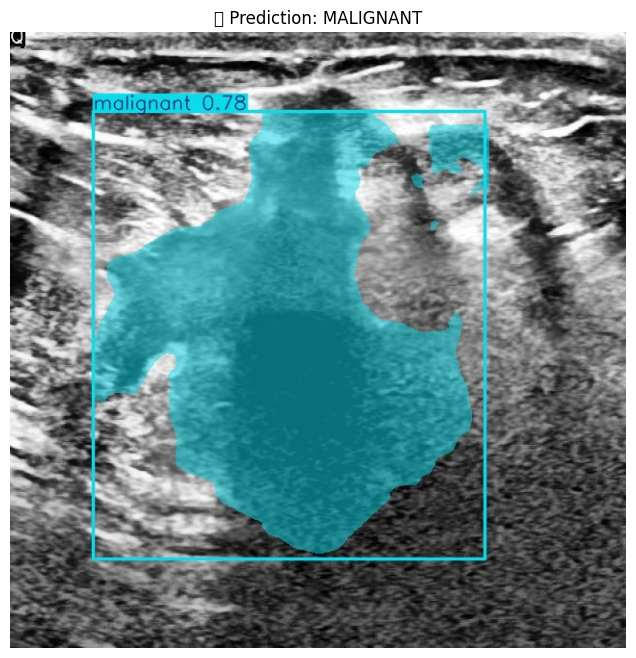

✅ Image: malignant-25-_png.rf.76192a3674dbb6760b12c6a91f514c76.jpg
   ➤ Prediction: MALIGNANT
   ➤ Saved Result: runs\segment\predict\malignant-25-_png.rf.76192a3674dbb6760b12c6a91f514c76.jpg



In [1]:
# ===========================================
# ✅ YOLO Segmentation Inference with "Normal" Auto-Label
# ===========================================

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2, os, glob

# -------------------------------
# 🔧 USER INPUTS
# -------------------------------
MODEL_PATH = r"D:\MY WORK\FYP_project\Breast_Ultrasound_Tumor_Segmentation\yolov8\model\runs\segment\train\weights\best.pt"   # your 2-class model
IMAGE_PATH = r"D:\MY WORK\FYP_project\Breast_Ultrasound_Tumor_Segmentation\Breast Lesion Segmentation.v1i.yolov11\test\images\malignant-25-_png.rf.76192a3674dbb6760b12c6a91f514c76.jpg"  # folder or image path

# -------------------------------
# 🚀 Run YOLO Prediction
# -------------------------------
model = YOLO(MODEL_PATH)

results = model.predict(
    source=IMAGE_PATH,
    imgsz=640,
    conf=0.25,
    save=True,
    verbose=False
)

# -------------------------------
# 🔍 Process Results
# -------------------------------
output_dir = str(results[0].save_dir)
saved_images = glob.glob(os.path.join(output_dir, "*.*"))
if not saved_images:
    raise FileNotFoundError("❌ No result image found in output directory.")

# display each image result
for i, res in enumerate(results):
    img_path = res.path
    preds = res.boxes
    classes = res.names
    detected_labels = []

    if preds is not None and len(preds) > 0:
        for c in preds.cls.cpu().numpy():
            detected_labels.append(classes[int(c)])
        detected_labels = list(set(detected_labels))
    else:
        detected_labels = ["normal"]

    # -------------------------------
    # 🖼️ Load and Display Image
    # -------------------------------
    filename = os.path.basename(img_path)
    result_img_path = os.path.join(output_dir, filename)
    if not os.path.exists(result_img_path):
        # fallback to first saved result
        result_img_path = saved_images[min(i, len(saved_images)-1)]

    img = cv2.imread(result_img_path)
    if img is None:
        print(f"⚠️ Could not load {result_img_path}")
        continue

    label_text = ", ".join(detected_labels).upper()

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"🩻 Prediction: {label_text}")
    plt.axis("off")
    plt.show()

    print(f"✅ Image: {filename}")
    print(f"   ➤ Prediction: {label_text}")
    print(f"   ➤ Saved Result: {result_img_path}\n")
